In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [4]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

In [5]:
customers = customers.drop_duplicates()
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()

In [6]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [7]:
customers.to_csv("../data/cleaned/customers_clean.csv", index=False)
orders.to_csv("../data/cleaned/orders_clean.csv", index=False)
order_items.to_csv("../data/cleaned/order_items_clean.csv", index=False)
products.to_csv("../data/cleaned/products_clean.csv", index=False)
payments.to_csv("../data/cleaned/payments_clean.csv", index=False)

In [8]:
conn = sqlite3.connect("../ecommerce.db")

In [9]:
customers.to_sql("customers", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)

103886

In [10]:
query = """
SELECT order_status, COUNT(*) as total_orders
FROM orders
GROUP BY order_status
"""

df = pd.read_sql(query, conn)
df

,order_status,total_orders
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


In [11]:
query = """
SELECT strftime('%Y-%m', order_purchase_timestamp) AS month,
COUNT(order_id) AS total_orders
FROM orders
GROUP BY month
ORDER BY month
"""

monthly_orders = pd.read_sql(query, conn)
monthly_orders

,month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


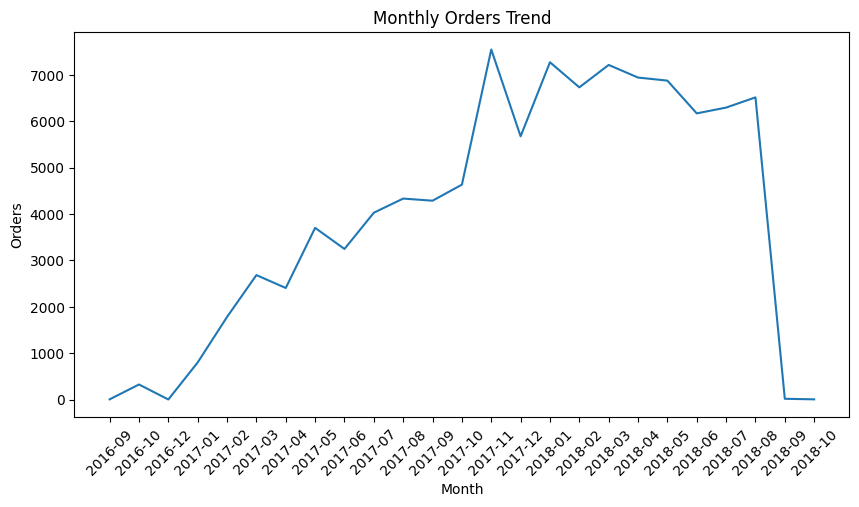

In [12]:
plt.figure(figsize=(10,5))
plt.plot(monthly_orders["month"], monthly_orders["total_orders"])
plt.xticks(rotation=45)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()